<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 >Avance de Tesis - PASO 3 -CIENCIA DE DATOS </strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  12/02/2026 - UPDATE FINAL</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2025-2</strong></p>
</div>

---

# **I) ETAPA 1**

# **0. LIBRERIAS**

In [2]:
# =============================================================================
# MODULO DE PREPROCESAMIENTO PARA CINTILACIONES IONOSFÉRICAS
# Autor: Alexander Valdez Portocarrero
# Descripción: Carga, análisis exploratorio y preparación de tensores para LSTM
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf # Solo si necesitas verificar GPU aquí
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Importaciones específicas de Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

2026-02-16 16:05:04.033167: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-16 16:05:04.297779: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771275904.399779    6057 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771275904.429477    6057 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771275904.623423    6057 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# **1. CARGA DE DATOS**

In [3]:
def cargar_dataset(path, filename):
    """
    Carga el CSV y realiza la conversión inicial de fechas.
    """
    full_path = os.path.join(path, filename)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"No se encontró el archivo en: {full_path}")

    print(f"📂 Cargando archivo: {filename}...")
    df = pd.read_csv(full_path)

    # Conversión única y definitiva a datetime
    df["Tiempo"] = pd.to_datetime(df["Tiempo"])

    # Ordenar cronológicamente (vital para series temporales)
    df = df.sort_values("Tiempo")

    print(f"✅ Dataset cargado. Shape: {df.shape}")
    print(f"   Rango de fechas: {df['Tiempo'].min()} a {df['Tiempo'].max()}")
    return df

# **2. ANALISIS EXPLORATORIO(EDA)**

In [4]:
def analizar_eventos_cintilacion(df, umbral_s4=0.6, plot=True):
    """
    Analiza y visualiza los días con presencia de cintilación.
    No modifica el DF original permanentemente, solo reporta estadísticas.
    """
    print("\n🔍 Analizando distribución de eventos...")

    # Trabajamos con una copia ligera para no alterar el original
    df_analisis = df[["Tiempo", "S4"]].copy()
    df_analisis["Fecha"] = df_analisis["Tiempo"].dt.date

    # 1. Identificar si cada día superó el umbral
    resumen_diario = df_analisis.groupby("Fecha")["S4"].max() > umbral_s4
    resumen_diario = resumen_diario.reset_index()
    resumen_diario.columns = ["Fecha", "Evento_Cintilacion"] # True/False

    total_dias = resumen_diario["Fecha"].nunique()
    dias_con_evento = resumen_diario["Evento_Cintilacion"].sum()

    print(f"   Total de días registrados: {total_dias}")
    print(f"   Días con eventos (S4 > {umbral_s4}): {dias_con_evento}")
    print(f"   Porcentaje de actividad: {(dias_con_evento/total_dias)*100:.2f}%")

    # 2. Reporte Mensual
    df_analisis["Mes"] = df_analisis["Tiempo"].dt.to_period("M")

    # Unimos para saber qué día tuvo evento
    # Primero agrupamos por día para saber si ESE día hubo evento
    max_s4_dia = df_analisis.groupby(["Mes", "Fecha"])["S4"].max().reset_index()
    max_s4_dia["Tuvo_Evento"] = (max_s4_dia["S4"] > umbral_s4).astype(int)

    # Tabla resumen
    tabla_mensual = max_s4_dia.groupby("Mes")["Tuvo_Evento"].agg(
        Dias_Con_Cintilacion='sum',
        Total_Dias='count'
    )
    tabla_mensual["Dias_Sin_Cintilacion"] = tabla_mensual["Total_Dias"] - tabla_mensual["Dias_Con_Cintilacion"]

    print("\n📊 Resumen Mensual de Actividad:")
    print(tabla_mensual)

    # 3. Visualización (Opcional)
    if plot:
        plt.figure(figsize=(12, 5))
        # Convertimos a string para que matplotlib no haga lío con fechas
        fechas_str = resumen_diario["Fecha"].astype(str)
        valores = resumen_diario["Evento_Cintilacion"].astype(int)

        plt.bar(fechas_str, valores, color=np.where(valores==1, 'orange', 'skyblue'))
        plt.title(f"Días con Cintilación (S4 > {umbral_s4})")
        plt.ylabel("Presencia (1=Sí, 0=No)")
        plt.xticks(rotation=90, fontsize=8)

        # Mostrar solo una etiqueta cada 7 días para no saturar
        ax = plt.gca()
        for index, label in enumerate(ax.xaxis.get_ticklabels()):
            if index % 7 != 0:
                label.set_visible(False)

        plt.tight_layout()
        plt.show()

# **3. FEATURE ENGINEERING**

In [8]:
# =============================================================================
# 3. INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
# =============================================================================
def agregar_caracteristicas_temporales(df):
    """
    Agrega transformaciones cíclicas de tiempo (Seno/Coseno).
    """
    print("\n⚙️ Generando características temporales (Sin/Cos)...")

    # Calcular minuto del día (0–1439)
    minutos_dia = df["Tiempo"].dt.hour * 60 + df["Tiempo"].dt.minute
    periodo = 24 * 60 # 1440 minutos

    # Transformación
    df["Hora_Sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["Hora_Cos"] = np.cos(2 * np.pi * minutos_dia / periodo)

    return df

# **RESULTADOS Y EVALUACION**

RUTA : /home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook
Trabajamos con el archivo: df_FINAL_JICAMARCA.csv
📂 Cargando archivo: df_FINAL_JICAMARCA.csv...
✅ Dataset cargado. Shape: (449844, 15)
   Rango de fechas: 2025-01-26 00:35:00 a 2025-12-31 23:45:00

🔍 Analizando distribución de eventos...
   Total de días registrados: 328
   Días con eventos (S4 > 0.6): 65
   Porcentaje de actividad: 19.82%

📊 Resumen Mensual de Actividad:
         Dias_Con_Cintilacion  Total_Dias  Dias_Sin_Cintilacion
Mes                                                            
2025-01                     3           6                     3
2025-02                    15          26                    11
2025-03                    10          31                    21
2025-04                     2          29                    27
2025-05                     0          31                    31
2025-06                     0          27                    27
2025-07                     0          29 

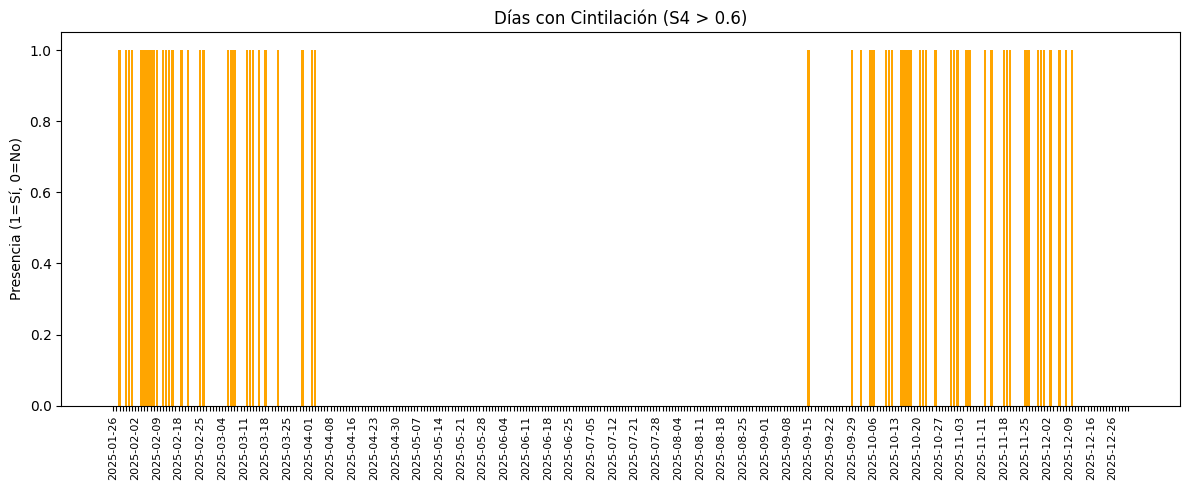


⚙️ Generando características temporales (Sin/Cos)...


In [10]:
if __name__ == "__main__":

    # 1. Configuración
    N_ESTACION  = 0  # Escoge la estacion
    ESTACION    = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]

    RUTA        = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
    #RUTA_DRIVE = "/content/drive/MyDrive/MAESTRIA_ARTICULO_2026/data"
    #RUTA_DRIVE  = "/content/drive/MyDrive/MAESTRIA_MCC_2024_2/PROCIENCIA_TESIS/DATA_2023_2025_PROC"
    #ARCHIVO         = "df_FINAL.csv"
    ARCHIVO     = f"df_FINAL_{ESTACION[N_ESTACION]}.csv"

    print("="*60)
    #print(f"RUTA DRIVE: {RUTA_DRIVE}")
    print(f"RUTA : {RUTA}")
    print(f"Trabajamos con el archivo: {ARCHIVO}")
    print("="*60)

    # Definición de Features para el modelo (Orden Importante)
    FEATURES_COLS = [
        'S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index',
        'Hora_Sin', 'Hora_Cos'
    ]

    # Parámetros Temporales
    LOOKBACK_MIN = 60
    HORIZON_MIN  = 10
    LOOKBACK_OPTS = [ 60]
    HORIZON_OPTS = [10]

    # 2. Pipeline de ejecución
    # Cargar
    df_raw = cargar_dataset(RUTA, ARCHIVO)
    #df_raw = cargar_dataset(RUTA_DRIVE, ARCHIVO)
    #df_raw = cargar_dataset(RUTA_DRIVE_HYO, ARCHIVO_HYO)

    # Analizar (No modifica df_raw)
    analizar_eventos_cintilacion(df_raw, umbral_s4=0.6, plot=True)

    # Ingeniería de Features (Modifica df_raw)
    df_features = agregar_caracteristicas_temporales(df_raw)

In [12]:
df_features

,Tiempo,ID_Satelite,Azimuth,Elevacion,is_Outlier,Cintilacion,TEC,ROTEC,ROTI,S4,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,Hora_Sin,Hora_Cos
0,2025-01-26 00:35:00,39.0,189.0,31.0,False,0.0,70.689140,-0.012351,0.010958,0.161,3.000000,-1.416667,2.00,165.40,29.083333,0.152123,0.988362
1,2025-01-26 00:36:00,205.0,61.0,62.0,False,0.0,70.778647,-0.010967,0.010961,0.166,3.000000,-1.400000,2.00,165.40,29.000000,0.156434,0.987688
2,2025-01-26 00:37:00,13.0,197.0,32.0,False,0.0,70.868153,-0.009583,0.010964,0.128,3.000000,-1.383333,2.00,165.40,28.916667,0.160743,0.986996
3,2025-01-26 00:38:00,205.0,61.0,62.0,False,0.0,70.957660,-0.008198,0.010966,0.134,3.000000,-1.366667,2.00,165.40,28.833333,0.165048,0.986286
4,2025-01-26 00:39:00,205.0,61.0,62.0,False,0.0,71.047166,-0.006814,0.010969,0.136,3.000000,-1.350000,2.00,165.40,28.750000,0.169350,0.985556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449839,2025-12-31 23:41:00,42.0,118.0,32.0,False,0.0,28.705915,0.003217,0.000796,0.119,16.833333,13.000000,6.05,163.98,3227.850000,-0.082808,0.996566
449840,2025-12-31 23:42:00,42.0,118.0,32.0,False,0.0,28.705915,0.003217,0.000796,0.111,17.000000,13.000000,6.10,163.96,3062.700000,-0.078459,0.996917
449841,2025-12-31 23:43:00,42.0,117.0,32.0,False,0.0,28.705915,0.003217,0.000796,0.092,17.166667,13.000000,6.15,163.94,2897.550000,-0.074108,0.997250
449842,2025-12-31 23:44:00,30.0,177.0,49.0,False,0.0,28.705915,0.003217,0.000796,0.106,17.333333,13.000000,6.20,163.92,2732.400000,-0.069756,0.997564


# **ETAPA II**

# **4. PREPARACIÓN FINAL DE ESTRUCTURA**

In [14]:
def finalizar_estructura_df(df, target_col="S4"):
    """
    Limpia columnas auxiliares, reordena y establece el índice temporal.
    Esta función deja el DF listo para entrar al Generador de Ventanas.
    """
    print("\n🧹 Finalizando estructura del DataFrame...")

    # 1. Asegurar índice temporal
    if df.index.name != 'Tiempo':
        df = df.set_index('Tiempo')

    df = df.sort_index()

    # 2. Reordenar columnas: Target al final (práctica estándar)
    cols = [c for c in df.columns if c != target_col]
    cols.append(target_col)
    df = df[cols]

    # 3. Eliminar columnas que ya no sirven para el modelo numérico
    # (Ej: Fechas string, columnas categóricas, etc.)
    cols_a_borrar = ["dias", "Fecha", "Mes", "minuto_del_dia", "Cintilacion"]
    # Borramos solo si existen
    cols_existentes = [c for c in cols_a_borrar if c in df.columns]

    if cols_existentes:
        df = df.drop(columns=cols_existentes)
        print(f"   Columnas eliminadas: {cols_existentes}")

    print(f"✅ DataFrame Final Listo. Shape: {df.shape}")
    print(f"   Columnas finales: {df.columns.tolist()}")

    return df

# **5. ESTRATEGIA DE DIVISIÓN DE DATOS -DATASPLITTING**

In [22]:
# =============================================================================
# 5. ESTRATEGIA DE DIVISIÓN DE DATOS (DATA SPLITTING)
# =============================================================================
def dividir_estratificado_por_dias(df, umbral_s4=0.6):
    """
    Divide el dataset asegurando que haya días con tormentas en Train, Val y Test.
    """
    print("\n✂️ Ejecutando división estratificada de datos...")

    # Trabajamos con copia para no afectar el original
    temp_df = df.copy()

    # Si la columna Fecha no existe (porque la borramos en el paso 4), la recuperamos del índice
    if 'Fecha' not in temp_df.columns:
        temp_df['Fecha'] = temp_df.index.date

    # 1. Identificar Días Activos vs Días Quietos
    resumen_diario = temp_df.groupby('Fecha')['S4'].max().reset_index()

    dias_activos = resumen_diario[resumen_diario['S4'] > umbral_s4]['Fecha'].values
    dias_quietos_original = resumen_diario[resumen_diario['S4'] <= umbral_s4]['Fecha'].values
    #dias_quietos = resumen_diario[resumen_diario['S4'] <= umbral_s4]['Fecha'].values

    #------ AQUI VAMOS A MODIFICAR--------#
    n_activos = len(dias_activos)
    dias_quietos = dias_quietos_original[:n_activos]
    #dias_quietos = resumen_diario[resumen_diario['S4'] <= umbral_s4]['Fecha'].values
    #--------------------------------------------------------------------------------

    print(f"   Total Días Activos encontrados: {len(dias_activos)}")
    print(f"   Total Días Quietos encontrados: {len(dias_quietos)}")

    # 2. Repartir los Días ACTIVOS (aprox 70/15/15)
    # Primero separamos Train (70%) del resto (30%)
    activos_train, activos_temp = train_test_split(dias_activos, test_size=0.3, random_state=42)
    # Luego separamos ese resto en Val (50% del resto) y Test (50% del resto)
    activos_val, activos_test = train_test_split(activos_temp, test_size=0.5, random_state=42)

    # 3. Repartir los Días QUIETOS (misma lógica)
    quietos_train, quietos_temp = train_test_split(dias_quietos, test_size=0.3, random_state=42)
    quietos_val, quietos_test = train_test_split(quietos_temp, test_size=0.5, random_state=42)

    # 4. Combinar las listas
    lista_dias_train = np.concatenate([activos_train, quietos_train])
    lista_dias_val = np.concatenate([activos_val, quietos_val])
    lista_dias_test = np.concatenate([activos_test, quietos_test])

    # 5. Crear los DataFrames Finales
    # Ordenamos por fecha para mantener la lógica temporal interna
    # NOTA: Usamos temp_df['Fecha'] para filtrar, pero devolvemos df (el original limpio)
    #       Para asegurar consistencia, filtramos temp_df y luego dropeamos 'Fecha' si fue agregada,
    #       o simplemente usamos el índice.

    # Filtrar usando las fechas
    train = temp_df[temp_df['Fecha'].isin(lista_dias_train)].sort_index()
    val = temp_df[temp_df['Fecha'].isin(lista_dias_val)].sort_index()
    test = temp_df[temp_df['Fecha'].isin(lista_dias_test)].sort_index()

    # Limpieza final: Si agregamos 'Fecha' temporalmente, la quitamos para dejar los datos limpios
    if 'Fecha' in train.columns:
        train = train.drop(columns=['Fecha'])
        val = val.drop(columns=['Fecha'])
        test = test.drop(columns=['Fecha'])

    return train, val, test


def auditar_division_datos(df, nombre_set, umbral_s4=0.6):
    """
    Función auxiliar para verificar que cada set tenga eventos.
    """
    # Recuperamos fecha del índice para el análisis
    fechas = df.index.date
    s4_values = df['S4'].values

    # Dataframe temporal para agrupar
    df_temp = pd.DataFrame({'Fecha': fechas, 'S4': s4_values})

    # Contar
    dias_totales = df_temp['Fecha'].nunique()
    dias_con_evento = df_temp[df_temp['S4'] > umbral_s4]['Fecha'].nunique()

    porcentaje = 0
    if dias_totales > 0:
        porcentaje = (dias_con_evento / dias_totales) * 100

    print(f"--- AUDITORÍA: {nombre_set.upper()} ---")
    print(f"📅 Días totales: {dias_totales}")
    print(f"⚡ Días con Cintilación: {dias_con_evento}")
    print(f"📊 Porcentaje actividad: {porcentaje:.2f}%")

    if dias_con_evento == 0:
        print(f"⚠️ PELIGRO: {nombre_set} NO tiene eventos. El modelo fallará aquí.")
    else:
        print("✅ Set válido.")
    print("-" * 30)

# **6.NORMALIZACION DE DATOS(SCALING)**

In [24]:
# =============================================================================
# 6. NORMALIZACIÓN DE DATOS (SCALING)
# =============================================================================
def escalar_preservando_indices(df_subset, scaler, cols, is_train=False):
    """
    Normaliza un DataFrame pero devuelve otro DataFrame con el mismo índice temporal.
    """
    if df_subset.empty:
        return df_subset

    # IMPORTANTE: Solo 'aprendemos' (fit) los máximos y mínimos con el set de TRAIN
    if is_train:
        scaler.fit(df_subset[cols])

    # Transformamos los datos (Matriz numpy)
    scaled_values = scaler.transform(df_subset[cols])

    # Reconstruimos el DataFrame pegándole el índice original
    df_scaled = pd.DataFrame(
        scaled_values,
        columns=cols,
        index=df_subset.index
    )

    # Añadimos la columna 'Fecha' para referencia (útil para depuración)
    # Si la columna no existe en el subset, la extraemos del índice
    if 'Fecha' in df_subset.columns:
        df_scaled['Fecha'] = df_subset['Fecha'].values
    else:
        df_scaled['Fecha'] = df_subset.index.date

    return df_scaled

def normalizar_sets(train_df, val_df, test_df, features_cols):
    """
    Aplica la normalización a los tres conjuntos de datos usando MinMaxScaler.
    """
    print("\n⚖️ Ejecutando Normalización (MinMaxScaler 0-1)...")

    # Inicializamos el escalador
    scaler = MinMaxScaler(feature_range=(0, 1))

    # 1. Normalizamos TRAIN (Aquí aprende el scaler)
    print("   -> Normalizando Train (Fit & Transform)")
    train_scaled = escalar_preservando_indices(train_df, scaler, features_cols, is_train=True)

    # 2. Normalizamos VAL y TEST (Usando lo aprendido en Train)
    print("   -> Normalizando Val (Transform only)")
    val_scaled = escalar_preservando_indices(val_df, scaler, features_cols, is_train=False)

    print("   -> Normalizando Test (Transform only)")
    test_scaled = escalar_preservando_indices(test_df, scaler, features_cols, is_train=False)

    # Verificación
    s4_min_orig = train_df['S4'].min()
    s4_max_orig = train_df['S4'].max()
    s4_min_scal = train_scaled['S4'].min()
    s4_max_scal = train_scaled['S4'].max()

    print(f"   ✅ Normalización completada.")
    print(f"   Rango S4 Original (Train): {s4_min_orig:.4f} a {s4_max_orig:.4f}")
    print(f"   Rango S4 Escalado (Train): {s4_min_scal:.4f} a {s4_max_scal:.4f}")

    return train_scaled, val_scaled, test_scaled, scaler

# **RESULTADOS Y EVALUACION**

In [26]:
# Estructura Final (Listo para LSTM)
df_final = finalizar_estructura_df(df_features, target_col="S4")
# Visualización rápida de las primeras filas del resultado final
print("\n--- PRIMERAS 5 FILAS DEL DF FINAL ---")
print(df_final.head())

# --- NUEVO PASO: DIVISIÓN ESTRATIFICADA ---
train_df, val_df, test_df = dividir_estratificado_por_dias(df_final, umbral_s4=0.6)

# Auditoría de la división
print("\n=== AUDITORÍA DE DISTRIBUCIÓN DE DATOS ===")
auditar_division_datos(train_df, "Train Set")
auditar_division_datos(val_df, "Validation Set")
auditar_division_datos(test_df, "Test Set")


🧹 Finalizando estructura del DataFrame...
   Columnas eliminadas: ['Cintilacion']
✅ DataFrame Final Listo. Shape: (449844, 15)
   Columnas finales: ['ID_Satelite', 'Azimuth', 'Elevacion', 'is_Outlier', 'TEC', 'ROTEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'ap_Index', 'f10.7_Index', 'AE_Index', 'Hora_Sin', 'Hora_Cos', 'S4']

--- PRIMERAS 5 FILAS DEL DF FINAL ---
                     ID_Satelite  Azimuth  Elevacion  is_Outlier        TEC  \
Tiempo                                                                        
2025-01-26 00:35:00         39.0    189.0       31.0       False  70.689140   
2025-01-26 00:36:00        205.0     61.0       62.0       False  70.778647   
2025-01-26 00:37:00         13.0    197.0       32.0       False  70.868153   
2025-01-26 00:38:00        205.0     61.0       62.0       False  70.957660   
2025-01-26 00:39:00        205.0     61.0       62.0       False  71.047166   

                        ROTEC      ROTI  Kp_Index  Dst_Index  ap_Index  \
Tiempo      

In [28]:
# --- NUEVO PASO: NORMALIZACIÓN ---
train_scaled, val_scaled, test_scaled, scaler = normalizar_sets(
    train_df, val_df, test_df, FEATURES_COLS
)

# Ejemplo de datos escalados
print("\n--- EJEMPLO DE DATOS ESCALADOS (TRAIN) ---")
print(train_scaled[['Hora_Sin', 'Hora_Cos', 'S4']].head(3))


⚖️ Ejecutando Normalización (MinMaxScaler 0-1)...
   -> Normalizando Train (Fit & Transform)
   -> Normalizando Val (Transform only)
   -> Normalizando Test (Transform only)
   ✅ Normalización completada.
   Rango S4 Original (Train): 0.0430 a 1.3860
   Rango S4 Escalado (Train): 0.0000 a 1.0000

--- EJEMPLO DE DATOS ESCALADOS (TRAIN) ---
                     Hora_Sin  Hora_Cos        S4
Tiempo                                           
2025-01-27 00:01:00  0.502182  1.000000  0.036485
2025-01-27 00:02:00  0.504363  0.999986  0.032762
2025-01-27 00:03:00  0.506545  0.999962  0.046165


# **ETAPA 3**

Vamos a realizar un **GRID SEARCH** (Busqueda de Cuadricula) sobre los parámetros de tiempo (lookback y horizon). Esto es fundamental para encontrar el punto mas apropiado donde el modelo tiene suficiente contexto histórico para predecir, pero no tanto como para introducir ruido, y un horizonte de prediccion que sea util operativamente sin perder precision.

## **PARAMETROS MODIFICABLES (TUNNING)**

Esta es la lista de parámetros que se puede modificar dentro de la función de construcción del modelo o del entrenamiento para refinar aun más (además de LookBack y Horizon)
1. **Función de Pérdida(weighted_focal_mse_multistep)**
   * beta(**Penalty Weight**): Actualmente en 15.0 o 50.0. Si el modelo ignora los picos, debemos subirlos(ejemplo: 60,80). Si el modelo inventan picos donde no hay (falsos positivos) se debe bajar.
   * alpha(Focal factor): Actualmente 1.5 o 2.0. Controla cuanto se enfoca en los ejemplos dificiles. Un valor mas alto obliga al modelo a corregir errores grandes.
2. **En la arquitectura del Modelo**
   * LSTM Units (128,64) Cantidad de neuronas. Para experimentos rápidos puedes bajarlo a (64,32) para ver si se ejecuta mas rapido sin perder mucha precisión.
   * Dropout(0.3): Si vems que val_loss  es mucho ams alto que loss(train) hay overfitting. Sube el dropout(ejemplo: 0.4 o 0.5)
3. **En el entrenamiento**
   * batch_size: Actualmente 64. Tenemos memoria GPU, 128 O 256 aceleran el entrenamiento. Si es muy pequeño (16,32), la actualizacion de pesos es mas ruidosa.

🏁 INICIANDO GRID SEARCH: 15 combinaciones.
   Lookbacks: [80, 90, 100]
   Horizons:  [5, 10, 15, 20, 30]

[1/15] 🧪 Probando: Lookback=80, Horizon=5 min...
   ✅ Resultado -> RMSE Global: 0.0741 | RMSE Evento: 0.2530

[2/15] 🧪 Probando: Lookback=80, Horizon=10 min...
   ✅ Resultado -> RMSE Global: 0.0811 | RMSE Evento: 0.2997

[3/15] 🧪 Probando: Lookback=80, Horizon=15 min...
   ✅ Resultado -> RMSE Global: 0.0882 | RMSE Evento: 0.2961

[4/15] 🧪 Probando: Lookback=80, Horizon=20 min...
   ✅ Resultado -> RMSE Global: 0.0913 | RMSE Evento: 0.3487

[5/15] 🧪 Probando: Lookback=80, Horizon=30 min...
   ✅ Resultado -> RMSE Global: 0.0971 | RMSE Evento: 0.3400

[6/15] 🧪 Probando: Lookback=90, Horizon=5 min...
   ✅ Resultado -> RMSE Global: 0.0617 | RMSE Evento: 0.2609

[7/15] 🧪 Probando: Lookback=90, Horizon=10 min...
   ✅ Resultado -> RMSE Global: 0.0917 | RMSE Evento: 0.2903

[8/15] 🧪 Probando: Lookback=90, Horizon=15 min...
   ✅ Resultado -> RMSE Global: 0.0877 | RMSE Evento: 0.3185

[9/15] 🧪

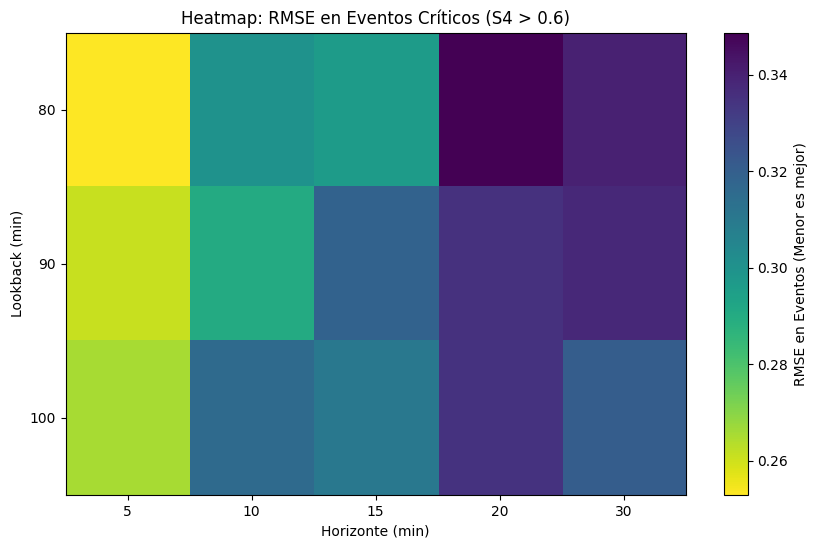

In [32]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# =============================================================================
# 1. PREPARACIÓN DE DATOS (Generadores de Ventanas)
# =============================================================================

def crear_dataset_lstm_multistep_con_gaps(df, cols_input, col_target, lookback=60, horizon=20):
    """Genera tensores X e y verificando continuidad temporal estricta."""
    data_values = df[cols_input].values
    target_values = df[col_target].values
    timestamps = df.index.to_series().values
    
    X, y = [], []
    
    # Bucle optimizado
    for i in range(lookback, len(df) - horizon):
        # Timestamps clave
        t_inicio = timestamps[i - lookback]
        t_actual = timestamps[i]
        t_fin_secuencia = timestamps[i + horizon - 1]
        
        # 1. Validar ventana entrada (Lookback)
        diff_entrada = (t_actual - t_inicio) / np.timedelta64(1, 'm')
        if diff_entrada != lookback: continue
            
        # 2. Validar ventana salida (Horizonte total)
        diff_salida = (t_fin_secuencia - t_actual) / np.timedelta64(1, 'm')
        if diff_salida != (horizon - 1): continue
            
        # 3. Validar huecos internos en la salida (Gap check)
        # Tomamos el slice de tiempos futuros y verificamos diferencias
        tiempos_futuros = timestamps[i : i + horizon]
        diffs = np.diff(tiempos_futuros) / np.timedelta64(1, 'm')
        if not np.all(diffs == 1): continue
            
        # Si pasa todo:
        ventana_entrada = data_values[i - lookback : i]
        secuencia_salida = target_values[i : i + horizon]
        
        X.append(ventana_entrada)
        y.append(secuencia_salida)
        
    return np.array(X), np.array(y)

def generar_tensores_dinamicos(train_scaled, val_scaled, test_scaled, features_cols, 
                               lookback, horizon):
    """Genera los tensores al vuelo para el Grid Search."""
    target_col = 'S4'
    
    X_train, y_train = crear_dataset_lstm_multistep_con_gaps(train_scaled, features_cols, target_col, lookback, horizon)
    X_val, y_val = crear_dataset_lstm_multistep_con_gaps(val_scaled, features_cols, target_col, lookback, horizon)
    X_test, y_test = crear_dataset_lstm_multistep_con_gaps(test_scaled, features_cols, target_col, lookback, horizon)
    
    return X_train, y_train, X_val, y_val, X_test, y_test

# =============================================================================
# 2. DEFINICIÓN DEL MODELO Y PÉRDIDA (LOSS)
# =============================================================================

def weighted_focal_mse_multistep(threshold, alpha=1.5, beta=50.0):
    """
    Función de pérdida personalizada.
    beta: Penalización para valores >= threshold (S4 alto).
    alpha: Factor focal para errores grandes.
    """
    def loss(y_true, y_pred):
        error = y_pred - y_true
        squared_error = tf.square(error)
        
        # Ponderación por umbral (físico)
        weights = tf.where(y_true >= threshold, beta, 1.0)
        
        # Penalización Focal (matemático)
        focal_weight = tf.pow(tf.abs(error) + 1e-7, alpha)
        
        # Penalización por Subestimación (seguridad)
        # Si es un evento alto y predigo bajo, castigo doble
        underestimation_mask = tf.logical_and(y_true >= threshold, y_pred < y_true * 0.8)
        under_penalty = tf.where(underestimation_mask, 2.0, 1.0)
        
        total_loss = squared_error * weights * focal_weight * under_penalty
        return tf.reduce_mean(total_loss)
    return loss

def construir_modelo_simple(input_shape, output_steps, umbral_norm, penalty_beta=50.0):
    """
    Arquitectura 'Baseline' o Simple para el Grid Search.
    """
    tf.keras.backend.clear_session() # Limpiar memoria GPU/CPU
    
    model = Sequential([
        Input(shape=input_shape),
        
        # Encoder
        Bidirectional(LSTM(128, return_sequences=True, activation='tanh')),
        BatchNormalization(),
        Dropout(0.3),
        
        Bidirectional(LSTM(64, return_sequences=False, activation='tanh')),
        BatchNormalization(),
        Dropout(0.3),
        
        # Decoder
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        
        # Salida Vectorial
        Dense(output_steps, activation='linear') 
    ], name=f"LSTM_LB{input_shape[0]}_H{output_steps}")
    
    loss_fn = weighted_focal_mse_multistep(threshold=umbral_norm, alpha=1.5, beta=penalty_beta)
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss=loss_fn, 
                  metrics=['mae'])
    
    return model

# =============================================================================
# 3. UTILITARIOS DE EVALUACIÓN
# =============================================================================

def desnormalizar_y_evaluar(model, X_test, y_test, scaler, features_cols, umbral_real=0.6):
    """Predice, desnormaliza y calcula métricas separadas."""
    # 1. Predecir
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # 2. Desnormalizar
    idx_s4 = features_cols.index('S4')
    min_s4 = scaler.data_min_[idx_s4]
    max_s4 = scaler.data_max_[idx_s4]
    range_s4 = max_s4 - min_s4
    
    y_pred_real = (y_pred_scaled * range_s4) + min_s4
    y_test_real = (y_test * range_s4) + min_s4
    
    # 3. Métricas
    flat_true = y_test_real.flatten()
    flat_pred = y_pred_real.flatten()
    
    # Globales
    rmse_global = np.sqrt(mean_squared_error(flat_true, flat_pred))
    mae_global = mean_absolute_error(flat_true, flat_pred)
    
    # Eventos (S4 >= 0.6)
    mask = flat_true >= umbral_real
    if np.sum(mask) > 0:
        rmse_event = np.sqrt(mean_squared_error(flat_true[mask], flat_pred[mask]))
        mae_event = mean_absolute_error(flat_true[mask], flat_pred[mask])
    else:
        rmse_event, mae_event = 0.0, 0.0
        
    return rmse_global, mae_global, rmse_event, mae_event

# =============================================================================
# 4. MOTOR DEL GRID SEARCH
# =============================================================================

def ejecutar_grid_search(train_scaled, val_scaled, test_scaled, scaler, features_cols, 
                         lookbacks, horizons, umbral_s4_real=0.6):
    
    resultados = []
    
    # Calcular umbral normalizado para la Loss Function
    idx_s4 = features_cols.index('S4')
    umbral_norm = (umbral_s4_real - scaler.data_min_[idx_s4]) / (scaler.data_max_[idx_s4] - scaler.data_min_[idx_s4])
    
    total_iteraciones = len(lookbacks) * len(horizons)
    contador = 0
    
    print(f"🏁 INICIANDO GRID SEARCH: {total_iteraciones} combinaciones.")
    print(f"   Lookbacks: {lookbacks}")
    print(f"   Horizons:  {horizons}")
    
    for lb in lookbacks:
        for hz in horizons:
            contador += 1
            print(f"\n[{contador}/{total_iteraciones}] 🧪 Probando: Lookback={lb}, Horizon={hz} min...")
            
            # 1. Generar datos específicos para esta combinación
            X_train, y_train, X_val, y_val, X_test, y_test = generar_tensores_dinamicos(
                train_scaled, val_scaled, test_scaled, features_cols, lb, hz
            )
            
            if len(X_train) == 0:
                print("   ⚠️ No hay suficientes datos para esta ventana. Saltando...")
                continue
                
            # 2. Construir modelo
            input_shape = (lb, len(features_cols))
            model = construir_modelo_simple(input_shape, hz, umbral_norm)
            
            # 3. Entrenar (Ciclo corto para grid search, e.g., 30-50 epochs)
            # Usamos EarlyStopping agresivo para no perder tiempo en modelos malos
            early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
            reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
            
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=40,            # Suficiente para ver convergencia en Grid Search
                batch_size=128,       # Batch más grande para ir más rápido
                callbacks=[early_stop, reduce_lr],
                verbose=0             # Silencio para no llenar la consola
            )
            
            # 4. Evaluar
            rmse_g, mae_g, rmse_e, mae_e = desnormalizar_y_evaluar(
                model, X_test, y_test, scaler, features_cols, umbral_s4_real
            )
            
            print(f"   ✅ Resultado -> RMSE Global: {rmse_g:.4f} | RMSE Evento: {rmse_e:.4f}")
            
            # 5. Guardar métricas
            resultados.append({
                'Lookback': lb,
                'Horizon': hz,
                'RMSE_Global': rmse_g,
                'MAE_Global': mae_g,
                'RMSE_Evento': rmse_e,
                'MAE_Evento': mae_e,
                'Epochs': len(history.epoch)
            })
            
    # Convertir a DataFrame
    df_res = pd.DataFrame(resultados)
    df_res = df_res.sort_values(by='RMSE_Evento') # Ordenar por el mejor en eventos
    
    return df_res

# =============================================================================
# 5. EJECUCIÓN PRINCIPAL
# =============================================================================

if __name__ == "__main__":
    
    # IMPORTANTE: Aquí asumo que ya tienes 'train_scaled', 'val_scaled', 'test_scaled', 'scaler'
    # cargados en memoria del paso anterior. Si no, cárgalos aquí.
    
    # OPCIONES PARA EL GRID SEARCH
    # ---------------------------------------------------------
    LOOKBACK_OPTS = [80, 90, 100] #50, 60, 70, 80, 90, 100]
    HORIZON_OPTS  = [5, 10, 15, 20, 30]
    
    # Ejecutar experimento
    df_grid_results = ejecutar_grid_search(
        train_scaled, val_scaled, test_scaled, 
        scaler, FEATURES_COLS, 
        LOOKBACK_OPTS, HORIZON_OPTS
    )
    
    print("\n\n🏆 TOP 5 MEJORES CONFIGURACIONES (Por RMSE en Eventos):")
    print(df_grid_results.head(5))
    
    # Guardar CSV
    df_grid_results.to_csv("resultados_grid_search_lstm.csv", index=False)
    
    # Visualización simple (Mapa de calor de RMSE Evento)
    try:
        pivot_table = df_grid_results.pivot(index='Lookback', columns='Horizon', values='RMSE_Evento')
        plt.figure(figsize=(10, 6))
        plt.imshow(pivot_table, cmap='viridis_r', aspect='auto')
        plt.colorbar(label='RMSE en Eventos (Menor es mejor)')
        plt.xlabel('Horizonte (min)')
        plt.ylabel('Lookback (min)')
        plt.xticks(range(len(pivot_table.columns)), pivot_table.columns)
        plt.yticks(range(len(pivot_table.index)), pivot_table.index)
        plt.title('Heatmap: RMSE en Eventos Críticos (S4 > 0.6)')
        plt.show()
    except Exception as e:
        print("No se pudo generar el heatmap (posiblemente falta de datos completos en la matriz).")